# **Distances Inter-Amino Acid**

## 📦 **Package Import**

In [1]:
# python
import pandas as pd
from IPython.display import display, Markdown
import sys
import os
from pathlib import Path

# PepProtGraphAnalyzer framework
sys.path.append('/home/jovyan/work/PepProtGraphAnalyzer')
from PepProtGraphAnalyzer.module.notebook import NotebookApp
from PepProtGraphAnalyzer.util.plotting import boxplot, histogram

# init framework backend
app = NotebookApp('.env.jupyter.StarPep')
paths = app.paths()

[2025-09-23 19:24:01,819] WARNING [data_validator.py:87] Sequences with non-natural amino acids were excluded. See: /home/jovyan/work/output/out_paper/Starpep/Log/Sequences with Non-Natural Amino Acids.csv
[2025-09-23 19:24:09,338] INFO [notebook.py:70] Setting:
dataset_path: /home/jovyan/work/PepProtGraphAnalyzer/dataset/StarPep/StarPep.csv
pdb_path: /home/jovyan/work/PepProtGraphAnalyzer/dataset/StarPep/ESMFold_pdbs
notebook_output_path: /home/jovyan/work/output/out_paper/Starpep
sequence_analysis_path: /home/jovyan/work/PepProtGraphAnalyzer/output/results_with_seq_10_to_100/StarPep/2025-04-07T19.42.20-Sequence_Analyzer
graph_analysis_path: /home/jovyan/work/PepProtGraphAnalyzer/output/results_with_seq_10_to_100/StarPep/2025-04-07T19.56.31-Graph_Analyzer
min_seq_len: 10
max_seq_len: 100


## 📊 **Data Analysis**

### **Statistics of Inter-Amino Acid Distances**

In [2]:
statistics = pd.read_csv(app.sequence_analysis['sequence_inter_amino_acid_distances_summary'])
statistics

,distance_function,count,min,mean,std,p25,p50,p75,max,skewness,kurtosis
0,euclidean,25688946,7.187549e-01,20.126474,13.689747,10.283634,16.613239,26.241980,254.056279,1.542797,6.937100
1,canberra,25688946,1.253596e-02,1.085541,0.597095,0.615481,1.014184,1.471174,3.000000,0.588522,2.858140
2,lance_williams,25688946,5.685703e-03,0.339796,0.203929,0.178902,0.304133,0.465998,1.000000,0.750031,3.041840
3,clark,25688946,1.008155e-02,0.707474,0.361186,0.416101,0.681320,0.983046,1.732051,0.312449,2.366295
4,soergel,25688946,1.130712e-02,0.474613,0.217372,0.303506,0.466414,0.635742,1.000000,0.171448,2.229505
5,bhattacharyya,25688946,9.118815e-02,2.737850,1.620385,1.515764,2.430412,3.645232,20.357421,1.043045,4.339510
6,angular_separation,25688946,2.814799e-09,0.131011,0.164412,0.018027,0.065390,0.179948,1.000000,1.999451,7.267553


In [3]:
distance_functions = ['euclidean', 'bhattacharyya']
distances = app.get_distance_values(distance_functions)
distances

,euclidean,bhattacharyya
0,3.883721,1.652187
1,5.226176,1.426183
2,5.439519,1.903269
3,6.790649,2.517055
4,8.803020,2.700611
...,...,...
25878128,5.473478,1.200661
25878129,8.226947,2.261693
25878130,3.744016,0.578000
25878131,5.274944,1.560691


### **Analysis of the Distribution of Inter-Amino Acid Distances (*per Distance Function*)**

#### **Euclidean, Bhattacharyya** (*$0 ≤ d_{s,t} ≤ ∞$*) 

<br>**Euclidean, Bhattacharyya** (*$0 ≤ d_{s,t} ≤ ∞$*)<br>

<br>Statistics (*Euclidean, Bhattacharyya*)

,distance_function,count,min,mean,std,p25,p50,p75,max,skewness,kurtosis
0,euclidean,25688946,0.718755,20.126474,13.689747,10.283634,16.613239,26.241980,254.056279,1.542797,6.93710
1,bhattacharyya,25688946,0.091188,2.737850,1.620385,1.515764,2.430412,3.645232,20.357421,1.043045,4.33951


<br>Inter Amino Acid Distances (*Euclidean, Bhattacharyya*)

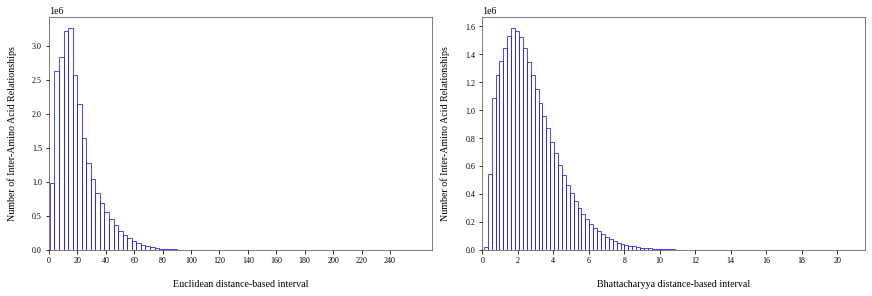

<br>Inter Amino Acid Distances (*Euclidean*)

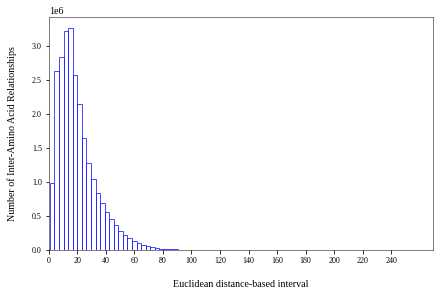

<br>Inter Amino Acid Distances (*Bhattacharyya*)

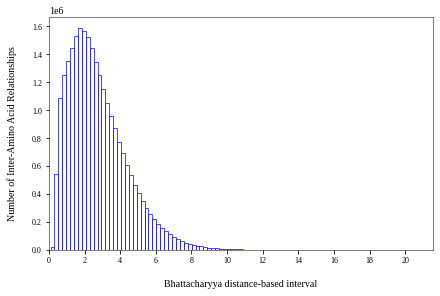

<br>Inter Amino Acid Distances (*Euclidean, Bhattacharyya*)

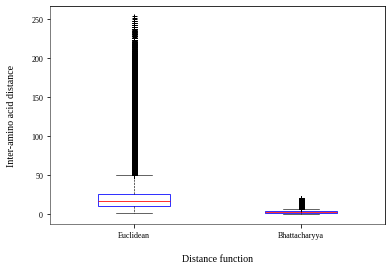

<br>Sequence with Largest Euclidean Distance: *RRLRPRRPRLPRPRPRPRPRPRSLPLPRPKPRPIPRPLPLPRPRPKPIPRPLPLPRPRPRRIPRPLPLPRPRPRPIPRPLPLPQPQPSPIPRPL*

Inter Amino Acid Distances (*Euclidean, Bhattacharyya*)

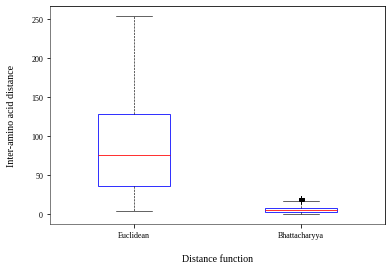

<br>Sequence with Largest Angular Separation Distance: *MWHLKLFAVLMICLLLLAQVDGSPIPQQSSAKRRPRRMTPFWRAVSLRPIGASCRDDSECITRLCRKRRCSLSVAQE*

Inter Amino Acid Distances (*Euclidean, Bhattacharyya*)

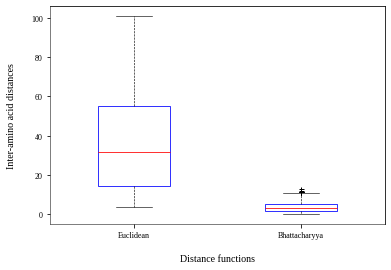

In [4]:
# distance functions 
distance_functions = ['euclidean', 'bhattacharyya']

# section name
display(Markdown("<br>**Euclidean, Bhattacharyya** (*$0 ≤ d_{s,t} ≤ ∞$*)<br>"))

# statistics
display(Markdown("<br>Statistics (*Euclidean, Bhattacharyya*)"))
display(statistics[statistics['distance_function'].isin(distance_functions)].reset_index(drop=True))

# histogram
distances = app.get_distance_values(distance_functions)

y_label = 'Number of Inter-Amino Acid Relationships'
x_labels = ['Euclidean distance-based interval', 'Bhattacharyya distance-based interval']
bin_width = [3.2, 0.22]
x_axis_step = [20, 2]

display(Markdown("<br>Inter Amino Acid Distances (*Euclidean, Bhattacharyya*)"))
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (eu_ba) -histogram ")
plt = histogram(distances, x_labels, y_label, bin_width=bin_width, x_axis_step=x_axis_step, output=output)
plt.show()

display(Markdown("<br>Inter Amino Acid Distances (*Euclidean*)"))
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (eu) -histogram")
plt = histogram(distances['euclidean'], x_labels[0], y_label, bin_width=bin_width[0], x_axis_step=x_axis_step[0], output=output)
plt.show()

display(Markdown("<br>Inter Amino Acid Distances (*Bhattacharyya*)"))
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (ba) -histogram")
plt = histogram(distances['bhattacharyya'], x_labels[1], y_label, bin_width=bin_width[1], x_axis_step=x_axis_step[1], output=output)
plt.show()
del distances, plt

# boxplot
distances = app.get_distance_values_and_pivot(distance_functions)
display(Markdown("<br>Inter Amino Acid Distances (*Euclidean, Bhattacharyya*)"))
x_axis = 'distance_function'
y_axis = 'value'
x_ticks = ['Euclidean', 'Bhattacharyya']
x_label = 'Distance function'
y_label = 'Inter-amino acid distance'
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (eu_ba) -boxplot")
y_lim=(-1, 240)
plt = boxplot(distances, x_axis, y_axis, x_label, y_label, x_ticks, y_lim=None, output=output, categories=distance_functions)
plt.show()
del distances, plt

# Sequence with Largest Euclidean Distance Value
result = app.get_sequences_with_largest_distance(distance_function='euclidean')
sequence = result['sequence'].item()
distances = app.get_distance_values_and_pivot(distance_functions, sequence)

display(Markdown(f"<br>Sequence with Largest Euclidean Distance: *{sequence}*"))
display(Markdown("Inter Amino Acid Distances (*Euclidean, Bhattacharyya*)"))

x_axis = 'distance_function'
y_axis = 'value'
x_ticks = ['Euclidean', 'Bhattacharyya']
x_label = 'Distance function'
y_label = 'Inter-amino acid distance'
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (eu_ba) -boxplot - (with_largest_eu_value)")
y_lim=(-1, 240)
plt = boxplot(distances, x_axis, y_axis, x_label, y_label, x_ticks, y_lim=None, output=output, categories=distance_functions)
plt.show()
del distances, plt

# Sequence with Largest Angular Separation Distance Value
result = app.get_sequences_with_largest_distance(distance_function='angular_separation')
sequence = result['sequence'].item()
distances = app.get_distance_values_and_pivot(distance_functions, sequence)

display(Markdown(f"<br>Sequence with Largest Angular Separation Distance: *{sequence}*"))
display(Markdown("Inter Amino Acid Distances (*Euclidean, Bhattacharyya*)"))

x_axis = 'distance_function'
y_axis = 'value'
x_ticks = ['Euclidean', 'Bhattacharyya']
x_label = 'Distance functions'
y_label = 'Inter-amino acid distances'
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (eu_ba) -boxplot - (with_largest_as_value)")
y_lim=(-1, 240)

plt = boxplot(distances, x_axis, y_axis, x_label, y_label, x_ticks, y_lim=None, output=output, categories=distance_functions)
plt.show()

del distances, plt

**Canberra, Clark** (*$0 ≤ d_{s,t} ≤ p : p = 3$*)

<br>**Canberra, Clark** (*$0 ≤ d_{s,t} ≤ p : p = 3$*)<br>

<br>Statistics (*Canberra, Clark*)

,distance_function,count,min,mean,std,p25,p50,p75,max,skewness,kurtosis
0,canberra,25688946,0.012536,1.085541,0.597095,0.615481,1.014184,1.471174,3.000000,0.588522,2.858140
1,clark,25688946,0.010082,0.707474,0.361186,0.416101,0.681320,0.983046,1.732051,0.312449,2.366295


<br>Inter Amino Acid Distances (*Canberra, Clark*)

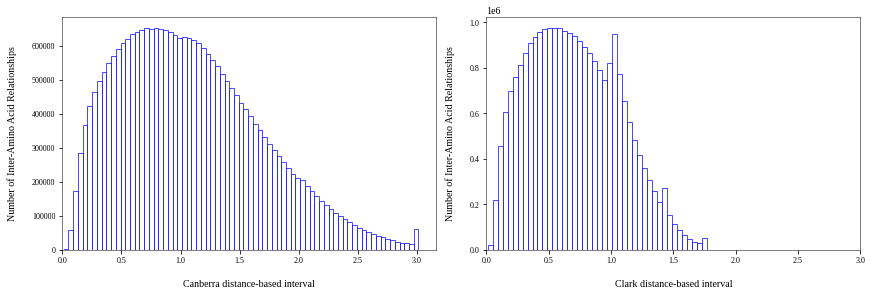

<br>Inter Amino Acid Distances (*Canberra*)

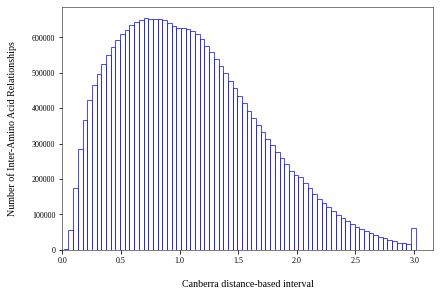

<br>Inter Amino Acid Distances (*Clark*)

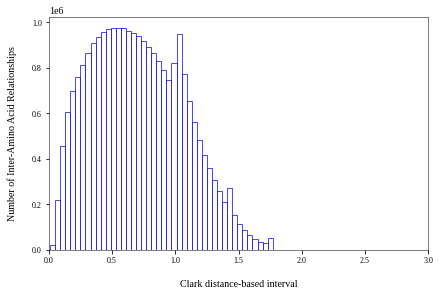

<br>Inter Amino Acid Distances (*Canberra, Clark*)

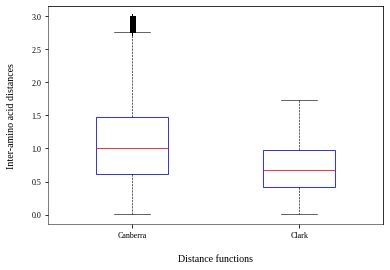

In [5]:
# distance functions
distance_functions = ['canberra', 'clark']

# section name
display(Markdown("<br>**Canberra, Clark** (*$0 ≤ d_{s,t} ≤ p : p = 3$*)<br>"))

# statistics
display(Markdown("<br>Statistics (*Canberra, Clark*)"))
display(statistics[statistics['distance_function'].isin(distance_functions)].reset_index(drop=True))

# histograms
distances = app.get_distance_values(distance_functions)

y_label = 'Number of Inter-Amino Acid Relationships'
x_labels = ['Canberra distance-based interval', 'Clark distance-based interval']
bin_width = 0.04
x_axis_step = 0.5

display(Markdown("<br>Inter Amino Acid Distances (*Canberra, Clark*)"))
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (ca_cl) -histogram")
plt = histogram(distances, x_labels, y_label, bin_width=bin_width, x_axis_step=x_axis_step, x_axis_max=3, output=output)
plt.show()

display(Markdown("<br>Inter Amino Acid Distances (*Canberra*)"))
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (ca) -histogram")
plt = histogram(distances['canberra'], x_labels[0], y_label, bin_width=bin_width, x_axis_step=x_axis_step, x_axis_max=3, output=output)
plt.show()

display(Markdown("<br>Inter Amino Acid Distances (*Clark*)"))
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (cl) -histogram")
plt = histogram(distances['clark'], x_labels[1], y_label, bin_width=bin_width, x_axis_step=x_axis_step, x_axis_max=3, output=output)
plt.show()

del distances, plt

# boxplot
distances = app.get_distance_values_and_pivot(distance_functions)

display(Markdown("<br>Inter Amino Acid Distances (*Canberra, Clark*)"))
x_axis = 'distance_function'
y_axis = 'value'
x_ticks = ['Canberra', 'Clark']
x_label = 'Distance functions'
y_label = 'Inter-amino acid distances'
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (ca_cl) -boxplot")
y_lim=(-1, 240)
plt = boxplot(distances, x_axis, y_axis, x_label, y_label, x_ticks, y_lim=None, output=output, categories=distance_functions)
plt.show()

del distances, plt

**Angular Separation, Lance Williams, Soergel** (*$0 ≤ d_{s,t} ≤ 1$*)

<br>**Angular Separation, Lance Williams, Soergel** (*$0 ≤ d_{s,t} ≤ 1$*)<br>

<br>Statistics (*Angular Separation, Lance Williams, Soergel*)

,distance_function,count,min,mean,std,p25,p50,p75,max,skewness,kurtosis
0,lance_williams,25688946,5.685703e-03,0.339796,0.203929,0.178902,0.304133,0.465998,1.0,0.750031,3.041840
1,soergel,25688946,1.130712e-02,0.474613,0.217372,0.303506,0.466414,0.635742,1.0,0.171448,2.229505
2,angular_separation,25688946,2.814799e-09,0.131011,0.164412,0.018027,0.065390,0.179948,1.0,1.999451,7.267553


<br>Inter Amino Acid Distances (*Angular Separation, Lance Williams, Soergel*)

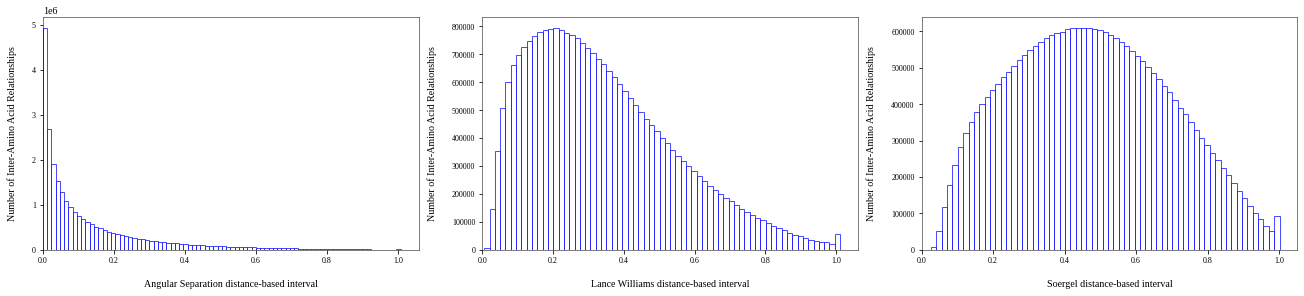

<br>Inter Amino Acid Distances (*Angular Separation)

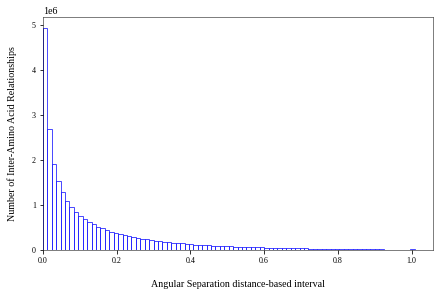

<br>Inter Amino Acid Distances (*Lance Williams*)

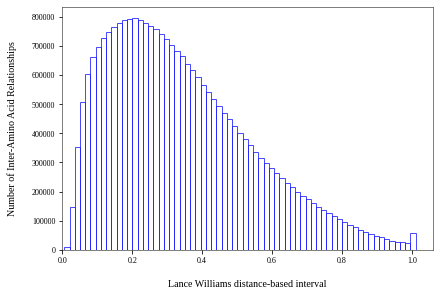

<br>Inter Amino Acid Distances (*Soergel*)

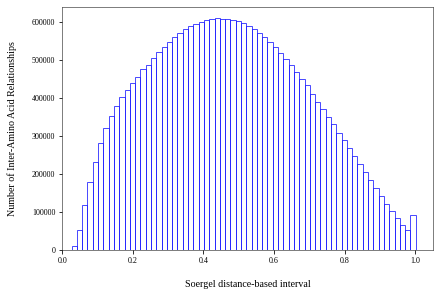

<br>Inter Amino Acid Distances (*Angular Separation, Lance Williams, Soergel*)

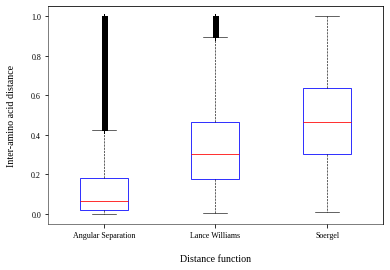

In [6]:
# distance_functions
distance_functions = ['angular_separation', 'lance_williams', 'soergel']

# section name
display(Markdown("<br>**Angular Separation, Lance Williams, Soergel** (*$0 ≤ d_{s,t} ≤ 1$*)<br>"))

# statistics
display(Markdown("<br>Statistics (*Angular Separation, Lance Williams, Soergel*)"))
display(statistics[statistics['distance_function'].isin(distance_functions)].reset_index(drop=True))

# histograms
distances = app.get_distance_values(distance_functions)

y_label = 'Number of Inter-Amino Acid Relationships'
x_labels = ['Angular Separation distance-based interval', 'Lance Williams distance-based interval', 'Soergel distance-based interval']
bin_width = [0.012, 0.015, 0.015]
x_axis_step = 0.2

display(Markdown("<br>Inter Amino Acid Distances (*Angular Separation, Lance Williams, Soergel*)"))
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (as_lw_so) -histogram")
plt = histogram(distances, x_labels, y_label, bin_width=bin_width, x_axis_step=x_axis_step, x_axis_max=1, output=output)
plt.show()

display(Markdown("<br>Inter Amino Acid Distances (*Angular Separation)"))
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (as) -histogram")
plt = histogram(distances['angular_separation'], x_labels[0], y_label, bin_width[0], x_axis_step, x_axis_max=1, output=output)
plt.show()

display(Markdown("<br>Inter Amino Acid Distances (*Lance Williams*)"))
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (lw) -histogram")
plt = histogram(distances['lance_williams'], x_labels[1], y_label, bin_width[1], x_axis_step, x_axis_max=1, output=output)
plt.show()

display(Markdown("<br>Inter Amino Acid Distances (*Soergel*)"))
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (so) -histogram")
plt = histogram(distances['soergel'], x_labels[2], y_label, bin_width[2], x_axis_step, x_axis_max=1, output=output)
plt.show()

del distances, plt

# boxplot
distances = app.get_distance_values_and_pivot(distance_functions)

display(Markdown("<br>Inter Amino Acid Distances (*Angular Separation, Lance Williams, Soergel*)"))
x_axis = 'distance_function'
y_axis = 'value'
x_ticks =['Angular Separation', 'Lance Williams', 'Soergel']
x_label = 'Distance function'
y_label = 'Inter-amino acid distance'
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (as_lw_so) -boxplot")
y_lim=(-1, 240)
plt = boxplot(distances, x_axis, y_axis, x_label, y_label, x_ticks, y_lim=None, output=output, categories=distance_functions)
plt.show()

del distances, plt

<br>Inter Amino Acid Distances (*Angular Separation, Lance Williams, Soergel*)

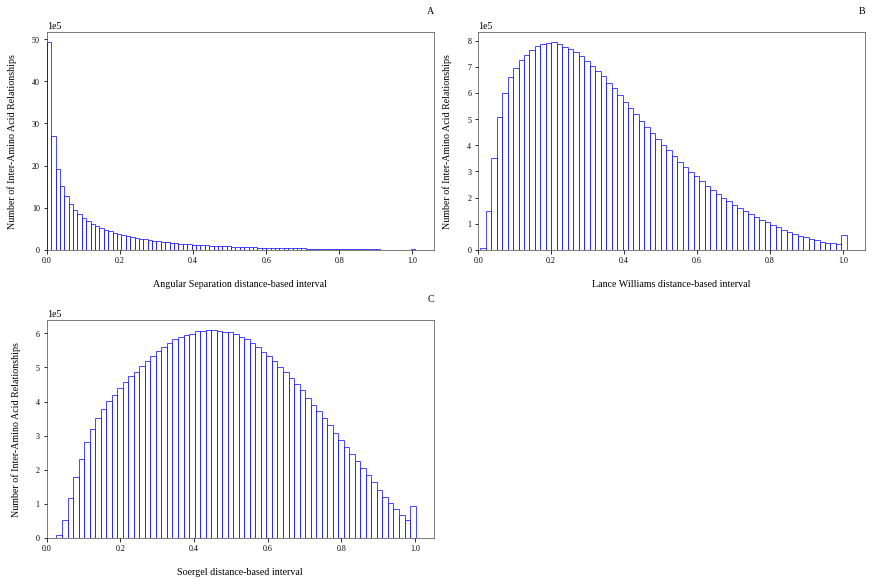

In [7]:
# distance_functions
distance_functions = ['angular_separation', 'lance_williams', 'soergel']

# histograms
distances = app.get_distance_values(distance_functions)

display(Markdown("<br>Inter Amino Acid Distances (*Angular Separation, Lance Williams, Soergel*)"))
y_label = 'Number of Inter-Amino Acid Relationships'
x_labels = ['Angular Separation distance-based interval', 'Lance Williams distance-based interval', 'Soergel distance-based interval']
bin_width = [0.012, 0.015, 0.015]
x_axis_step = 0.2
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (as_lw_so) -histogram_v)")
titles=['A', 'B', 'C']
plt = histogram(distances, x_labels, y_label, bin_width=bin_width, x_axis_step=x_axis_step, x_axis_max=1, output=output, titles=titles, n_cols=2, y_sci_limits=5, title_pad=18)
plt.show()

del distances, plt

<br>Sequence: *ALWKNMLKGIGKLAGKAALGAVKKLVGAES*

Inter Amino Acid Distances (*Angular Separation, Lance Williams, Soergel)

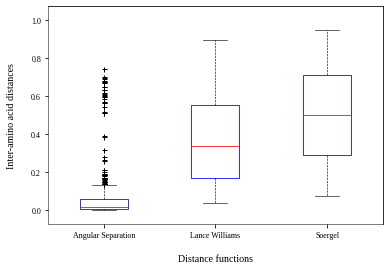

In [8]:
# Inter-amino acid Distance of the sequence 'ALWKNMLKGIGKLAGKAALGAVKKLVGAES'
distance_functions = ['angular_separation', 'lance_williams', 'soergel']
sequence = 'ALWKNMLKGIGKLAGKAALGAVKKLVGAES'
distances = app.get_distance_values_and_pivot(distance_functions, sequence)

display(Markdown("<br>Sequence: *ALWKNMLKGIGKLAGKAALGAVKKLVGAES*"))
display(Markdown("Inter Amino Acid Distances (*Angular Separation, Lance Williams, Soergel)"))
x_axis = 'distance_function'
y_axis = 'value'
x_ticks =['Angular Separation', 'Lance Williams', 'Soergel']
x_label = 'Distance functions'
y_label = 'Inter-amino acid distances'
output = paths['distances_inter_amino_acid_path'].joinpath("Inter Amino Acid Distances (as_lw_so) -boxplot (sequence)")
y_lim=(-0.07, 1.07)

plt = boxplot(distances, x_axis, y_axis, x_label, y_label, x_ticks, y_lim=y_lim, output=output, categories=distance_functions)
plt.show()

del distances, plt